### **Informe de Optimización de Modelo de Clasificación para el Dataset Titanic**

#### **1. Resumen**

El objetivo de este análisis fue optimizar un modelo `ClusteredCART` (KMeans + Árboles de Decisión) para predecir la supervivencia de los pasajeros del Titanic. El modelo inicial presentaba dos debilidades principales: **sobreajuste (overfitting)** a los datos de entrenamiento y una **baja capacidad para identificar a los supervivientes** (bajo recall en la clase minoritaria).

A través de un proceso iterativo de ajuste de hiperparámetros y análisis de resultados, se determinó que la estrategia más efectiva fue la implementación del parámetro **`class_weight='balanced'`** junto con una optimización de la poda del árbol (`ccp_alpha`). Esta configuración logró:

*   **Aumentar el F1-Score** en el conjunto de prueba de **0.672 a 0.734**.
*   **Mejorar drásticamente el Recall** (sensibilidad) para la clase "sobrevivió" de **0.58 a 0.78**.
*   **Elevar el AUC** de **0.782 a 0.819**, indicando una mejor capacidad de discriminación.
*   **Eliminar prácticamente el sobreajuste**, alineando el rendimiento en validación cruzada con el del conjunto de prueba.

Se investigó la adición de nuevas características (`Has_Cabin`, `FamilySize`), pero se concluyó que, aunque lógicamente potentes, degradaban el rendimiento del modelo actual, probablemente debido a que la arquitectura de hiperparámetros no estaba optimizada para la nueva complejidad de los datos.

El **modelo final seleccionado** es, por tanto, el optimizado con `class_weight='balanced'` y sin las características de ingeniería adicionales, representando el mejor equilibrio entre rendimiento y robustez.

---

#### **2. Punto de Partida: Análisis del Modelo Inicial**

El primer modelo evaluado, a pesar de tener una precisión (Accuracy) decente, ocultaba problemas significativos.

**Resultados del Modelo Inicial:**
*   **F1-Score (Hold-Out):** 0.672
*   **AUC (Hold-Out):** 0.782
*   **Matriz de Confusión:** 29 Falsos Negativos (29 supervivientes clasificados incorrectamente como fallecidos).
*   **Recall (Clase 1 - Sobrevivió):** 0.58

**Deducciones Clave:**
1.  **Bajo Recall:** El modelo solo era capaz de identificar al 58% de los pasajeros que realmente sobrevivieron. Era un modelo "pesimista" que tendía a predecir la clase mayoritaria (no sobrevivió).
2.  **Sobreajuste Severo:** Existía una gran brecha entre el rendimiento en la validación cruzada (F1 de ~0.76) y el rendimiento en el conjunto de prueba (F1 de 0.67). El modelo se había "aprendido de memoria" los datos de entrenamiento y no generalizaba bien a datos nuevos.

---

#### **3. Proceso de Optimización Iterativo**

##### **Iteración 1: Atacando el Desbalance y el Sobreajuste**

La primera y más impactante mejora se logró al abordar directamente los dos problemas identificados.

**Acciones Realizadas:**
1.  **Se introdujo `class_weight='balanced'` en el `GridSearchCV`:** Esta instrucción le dice al árbol de decisión que penalice más los errores cometidos en la clase minoritaria (sobrevivientes), forzándolo a aprender a identificarlos mejor.
2.  **Se ajustó el rango de `ccp_alpha`:** Se permitió al `GridSearchCV` explorar valores de poda más agresivos para simplificar los árboles y reducir el sobreajuste.

**Resultados del Modelo Optimizado (GANADOR):**
*   **F1-Score (Hold-Out):** **0.734**
*   **AUC (Hold-Out):** **0.819**
*   **Matriz de Confusión:** **15 Falsos Negativos** (se redujeron a la mitad).
*   **Recall (Clase 1 - Sobrevivió):** **0.78** (una mejora drástica).

**Deducciones y Conclusiones:**
*   El uso de `class_weight` fue **extremadamente efectivo** para balancear el trade-off entre Precisión y Recall, mejorando significativamente la utilidad del modelo.
*   El `GridSearch` encontró un valor óptimo de `ccp_alpha` de **0.008**, confirmando que la poda era esencial para combatir el sobreajuste. La diferencia entre el score de CV (~0.75) y el de test (0.73) se volvió mínima.

##### **Iteración 2: El Experimento con Ingeniería de Características**

Con una base sólida, se intentó mejorar aún más el modelo añadiendo características lógicamente potentes.

**Acciones Realizadas:**
*   Se añadieron las columnas `Has_Cabin` (si el pasajero tenía cabina asignada) y `FamilySize` (tamaño total de la familia a bordo).

**Resultados del Modelo con Nuevas Características:**
*   **F1-Score (Hold-Out):** 0.709 (▼ Empeoró)
*   **AUC (Hold-Out):** 0.777 (▼ Empeoró)
*   **Recall (Clase 1 - Sobrevivió):** 0.72 (▼ Empeoró)

**Deducciones y Análisis del Resultado Inesperado:**
Este resultado contraintuitivo no significa que las características fueran malas, sino que **el modelo no estaba preparado para ellas.**
1.  **Cambio en el Clustering:** Las nuevas variables, especialmente `Has_Cabin`, son muy dominantes. Alteraron por completo la forma en que `KMeans` agrupaba a los pasajeros, creando clusters que, aunque lógicamente coherentes, resultaron ser más difíciles de modelar para los árboles de decisión con los hiperparámetros existentes.
2.  **Necesidad de Re-Optimización:** La arquitectura de hiperparámetros que era óptima para los datos originales (ej. `max_depth=7`, `ccp_alpha=0.008`) ya no era la mejor para este nuevo conjunto de datos más complejo. El modelo probablemente necesitaba árboles más profundos o una configuración diferente para aprovechar la nueva información, pero la búsqueda actual no lo encontró.

---

#### **4. Veredicto Final y Modelo Seleccionado**

Tras analizar los resultados de las iteraciones, la conclusión es clara.

El **modelo ganador** es el que fue optimizado usando **`class_weight='balanced'` y un adecuado `ccp_alpha`, sin la adición de `Has_Cabin` y `FamilySize`**.

**Tabla Comparativa Final (Hold-Out Set):**

| Métrica | Modelo Inicial | **Modelo Optimizado (GANADOR)** | Modelo con Feature Engineering |
| :--- | :---: | :---: | :---: |
| **F1-Score** | 0.672 | **0.734** | 0.709 |
| **AUC** | 0.782 | **0.819** | 0.777 |
| **Recall (Sobrevivió)** | 0.58 | **0.78** | 0.72 |
| **Falsos Negativos** | 29 | **15** | 19 |
| **Sobreajuste** | Alto | **Mínimo** | Mínimo |

Este modelo no solo presenta las mejores métricas de rendimiento, sino que también ha demostrado ser robusto y generalizar bien a datos no vistos. La investigación con ingeniería de características fue un ejercicio valioso que enseñó que añadir más datos no garantiza una mejora si no se re-evalúa y re-ajusta la arquitectura completa del modelo.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import display, Image

plt.style.use('seaborn-v0_8-whitegrid')

Figura 1: Diagrama de la arquitectura del modelo ClusteredCART.


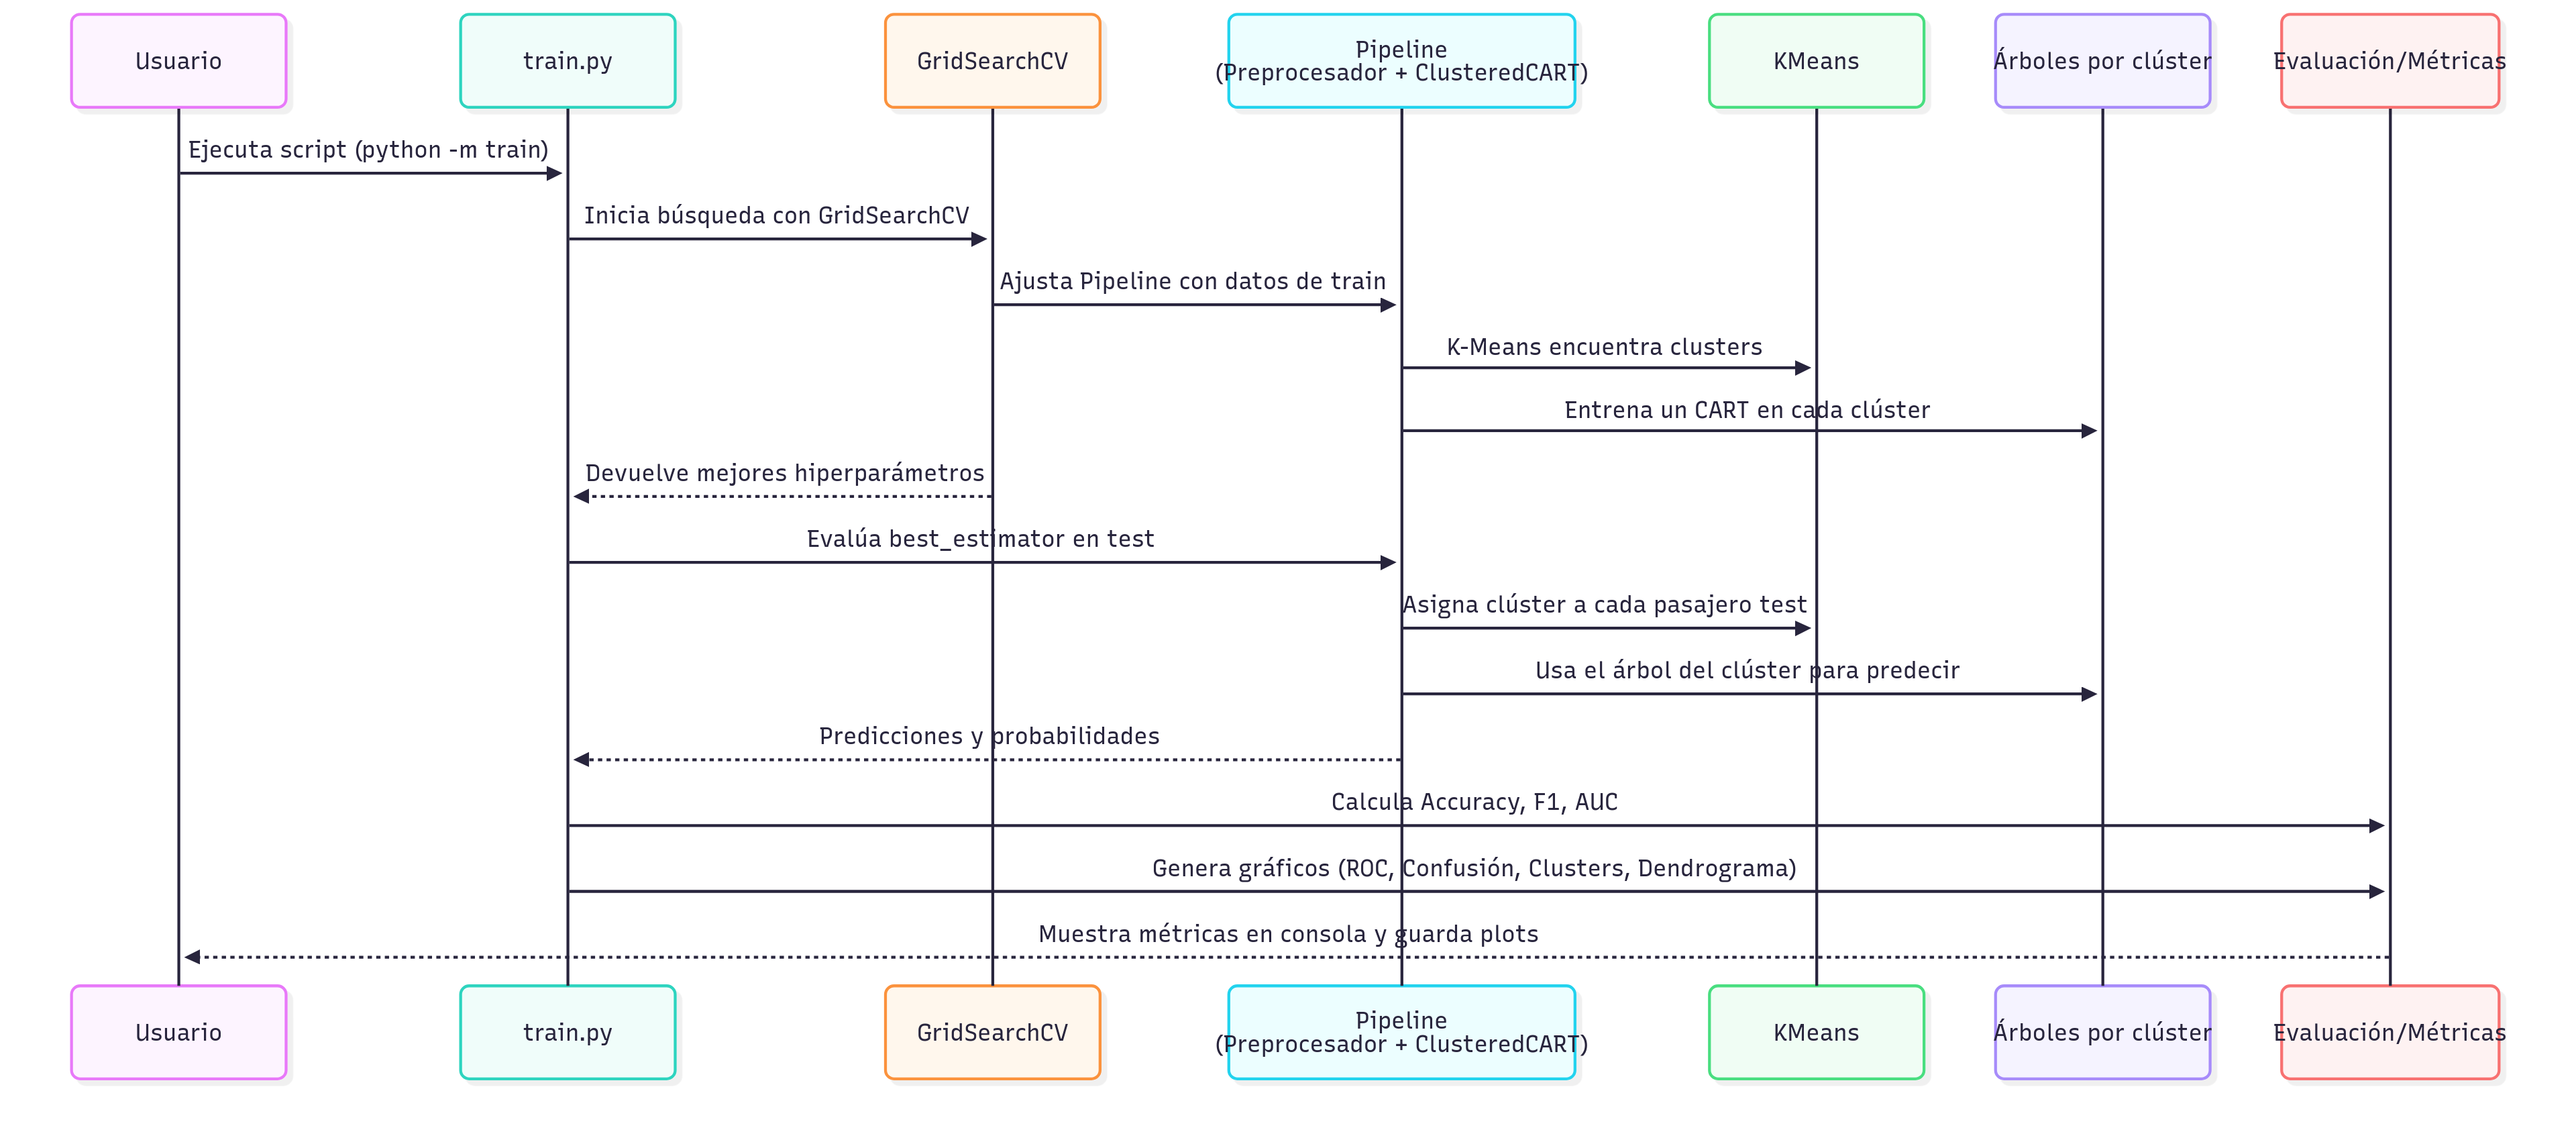

In [8]:
path_diagrama = 'titanic/src/conclusiones/diagramasec.png'

print("Figura 1: Diagrama de la arquitectura del modelo ClusteredCART.")
display(Image(filename=path_diagrama, width=1000)) 

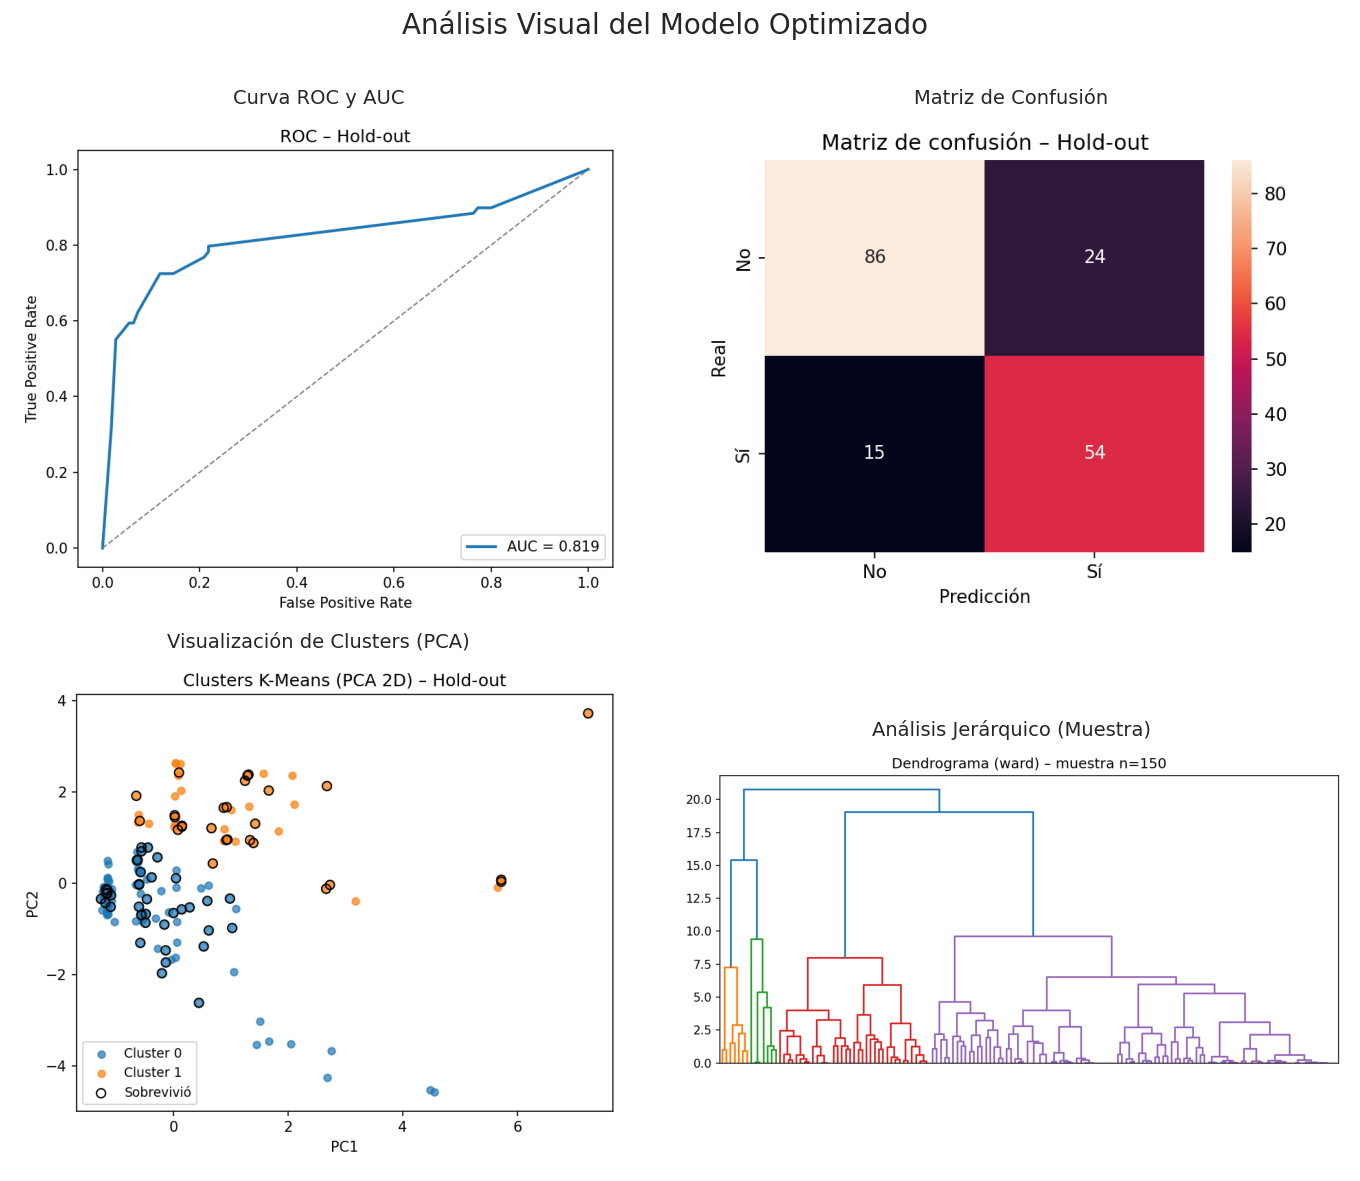

In [3]:
# --- Panel de Gráficos de Evaluación del Modelo Ganador ---

# Rutas a los gráficos generados por train.py
path_roc = 'titanic/src/plots/roc_holdout.png'
path_cm = 'titanic/src/plots/cm_holdout.png'
path_pca = 'titanic/src/plots/clusters_pca.png'
path_dendrogram = 'titanic/src/plots/dendrogram_sample.png'

# Creamos una figura con una cuadrícula de 2x2 para mostrar los 4 gráficos
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Análisis Visual del Modelo Optimizado', fontsize=20)

# Gráfico ROC
img_roc = mpimg.imread(path_roc)
axes[0, 0].imshow(img_roc)
axes[0, 0].set_title('Curva ROC y AUC', fontsize=14)
axes[0, 0].axis('off')  # Ocultamos los ejes para que se vea limpio

# Matriz de Confusión
img_cm = mpimg.imread(path_cm)
axes[0, 1].imshow(img_cm)
axes[0, 1].set_title('Matriz de Confusión', fontsize=14)
axes[0, 1].axis('off')

# Clusters PCA
img_pca = mpimg.imread(path_pca)
axes[1, 0].imshow(img_pca)
axes[1, 0].set_title('Visualización de Clusters (PCA)', fontsize=14)
axes[1, 0].axis('off')

# Dendrograma
img_dendrogram = mpimg.imread(path_dendrogram)
axes[1, 1].imshow(img_dendrogram)
axes[1, 1].set_title('Análisis Jerárquico (Muestra)', fontsize=14)
axes[1, 1].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.96]) # Ajusta el layout para que el título no se superponga
plt.show()

--- Vista Previa del DataFrame X Procesado ---
   Pclass     Sex   Age  SibSp  Parch     Fare Embarked
0       3    male  22.0      1      0   7.2500        S
1       1  female  38.0      1      0  71.2833        C
2       3  female  26.0      0      0   7.9250        S
3       1  female  35.0      1      0  53.1000        S
4       3    male  35.0      0      0   8.0500        S

--- Información y Tipos de Datos de X ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    891 non-null    int64  
 1   Sex       891 non-null    object 
 2   Age       714 non-null    float64
 3   SibSp     891 non-null    int64  
 4   Parch     891 non-null    int64  
 5   Fare      891 non-null    float64
 6   Embarked  889 non-null    object 
dtypes: float64(2), int64(3), object(2)
memory usage: 48.9+ KB
None


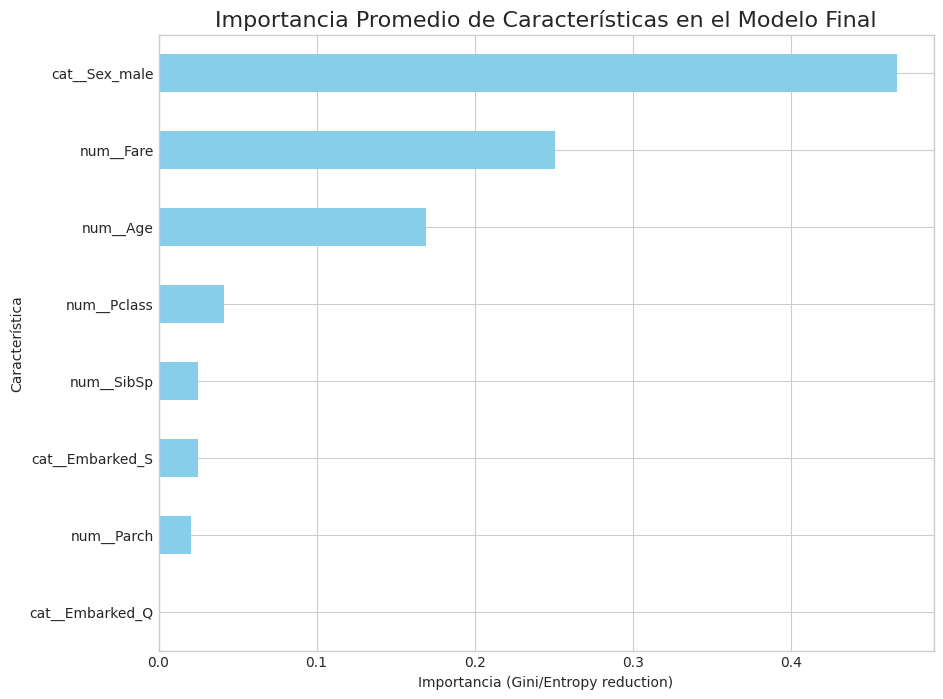

In [4]:
# Importamos tus propias funciones y clases
from titanic.src.data_pipeline import load_titanic, make_preprocessor, train_test_split_strat
from titanic.src.clustered_cart import ClusteredCART
from sklearn.pipeline import Pipeline

# 1. Cargamos los datos
X, y, num_cols, cat_cols = load_titanic()
Xtr, Xte, ytr, yte = train_test_split_strat(X, y)

# 2. Definimos el pipeline con los MEJORES hiperparámetros encontrados
# (Copia los mejores parámetros de la salida de tu script ganador)
best_params = {
    'n_clusters': 2,
    'criterion': 'entropy',
    'max_depth': 7,
    'min_samples_leaf': 2,
    'min_samples_split': 6,
    'ccp_alpha': 0.008,
    'class_weight': 'balanced'
}

pre = make_preprocessor(num_cols, cat_cols)
clf = ClusteredCART(random_state=42, **best_params)

pipe = Pipeline(steps=[
    ("pre", pre),
    ("clf", clf)
])

# 3. Entrenamos el mejor pipeline con TODOS los datos de entrenamiento
pipe.fit(Xtr, ytr)

# 4. Extraemos la importancia de las características
# Como tenemos múltiples árboles, promediamos su importancia
# Obtenemos los nombres de las features después del preprocesamiento
feature_names = pipe.named_steps['pre'].get_feature_names_out()
# Accedemos a los árboles entrenados dentro de ClusteredCART
trees = pipe.named_steps['clf'].trees_

# Calculamos la importancia promedio
avg_feature_importances = pd.DataFrame(
    [tree.feature_importances_ for tree in trees],
    columns=feature_names
).mean(axis=0)

# 5. Visualizamos los resultados
plt.figure(figsize=(10, 8))
avg_feature_importances.sort_values().plot(kind='barh', color='skyblue')
plt.title('Importancia Promedio de Características en el Modelo Final', fontsize=16)
plt.xlabel('Importancia (Gini/Entropy reduction)')
plt.ylabel('Característica')
plt.show()

In [5]:
# Usamos el pipeline ya entrenado en la celda anterior
y_pred = pipe.predict(Xte)

# Identificamos los errores
false_negatives = Xte[(y_pred == 0) & (yte == 1)]
false_positives = Xte[(y_pred == 1) & (yte == 0)]

print("--- Perfil de los Falsos Negativos ---")
print(f"El modelo predijo que {len(false_negatives)} personas NO sobrevivieron, pero SÍ lo hicieron.")
print("Analizando sus perfiles:")
display(false_negatives.head()) # Mostramos los primeros para ver patrones

print("\n\n--- Perfil de los Falsos Positivos ---")
print(f"El modelo predijo que {len(false_positives)} personas SÍ sobrevivieron, pero NO lo hicieron.")
print("Analizando sus perfiles:")
display(false_positives.head())

# Puedes agregar un .describe() para ver si hay patrones numéricos
print("\n\n--- Resumen Estadístico de los Errores vs. el Total ---")
print("\nEstadísticas del Test Set Completo:")
display(Xte.describe())
print("\nEstadísticas de Falsos Negativos:")
display(false_negatives.describe())
print("\nEstadísticas de Falsos Positivos:")
display(false_positives.describe())

--- Perfil de los Falsos Negativos ---
El modelo predijo que 15 personas NO sobrevivieron, pero SÍ lo hicieron.
Analizando sus perfiles:


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
553,3,male,22.0,0,0,7.2250,C
455,3,male,29.0,0,0,7.8958,C
65,3,male,NaN,1,1,15.2458,C
17,2,male,NaN,0,0,13.0000,S
679,1,male,36.0,0,1,512.3292,C




--- Perfil de los Falsos Positivos ---
El modelo predijo que 24 personas SÍ sobrevivieron, pero NO lo hicieron.
Analizando sus perfiles:


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
536,1,male,45.0,0,0,26.5500,S
698,1,male,49.0,1,1,110.8833,C
297,1,female,2.0,1,2,151.5500,S
40,3,female,40.0,1,0,9.4750,S
564,3,female,NaN,0,0,8.0500,S




--- Resumen Estadístico de los Errores vs. el Total ---

Estadísticas del Test Set Completo:


,Pclass,Age,SibSp,Parch,Fare
count,179.000000,139.000000,179.000000,179.000000,179.000000
mean,2.307263,29.250000,0.642458,0.346369,33.733145
std,0.848331,14.740355,1.252228,0.664193,55.843604
min,1.000000,0.750000,0.000000,0.000000,0.000000
25%,1.500000,19.500000,0.000000,0.000000,7.987500
50%,3.000000,27.000000,0.000000,0.000000,15.245800
75%,3.000000,35.000000,1.000000,0.000000,31.797900
max,3.000000,70.000000,8.000000,2.000000,512.329200



Estadísticas de Falsos Negativos:


,Pclass,Age,SibSp,Parch,Fare
count,15.000000,11.000000,15.000000,15.000000,15.000000
mean,2.133333,34.727273,0.200000,0.266667,53.505273
std,0.915475,17.590287,0.414039,0.457738,128.504882
min,1.000000,8.000000,0.000000,0.000000,0.000000
25%,1.000000,26.000000,0.000000,0.000000,7.845800
50%,2.000000,28.000000,0.000000,0.000000,13.000000
75%,3.000000,47.000000,0.000000,0.500000,35.500000
max,3.000000,62.000000,1.000000,1.000000,512.329200



Estadísticas de Falsos Positivos:


,Pclass,Age,SibSp,Parch,Fare
count,24.000000,19.000000,24.000000,24.000000,24.000000
mean,2.208333,26.368421,1.125000,0.416667,41.893400
std,0.977093,16.690684,1.392917,0.717282,37.578836
min,1.000000,1.000000,0.000000,0.000000,7.629200
25%,1.000000,14.500000,0.000000,0.000000,12.118750
50%,3.000000,29.000000,1.000000,0.000000,27.837500
75%,3.000000,42.000000,1.000000,1.000000,57.665600
max,3.000000,49.000000,5.000000,2.000000,151.550000
